# Challenge 2: Introduction to `Facebook prophet` 🔮



In this exercise, we will build a predictive model for Monthly Car Sales with Facebook Prophet.

[Prophet](https://facebook.github.io/prophet/docs/quick_start.html) is a **Python library** developed by Meta for time series predictions. Reminder, that **time series** is the field of data analytics and data science that deals with *sequentially recorded data* (such as monthly sales, daily temperature, daily stock prices...).

## Our first prediction - sales forecasting 🚗

Let's import Prophet and Pandas first.

In [ ]:
import pandas as pd
from prophet import Prophet

Then, import our data. For this exercise, we will look at how Python and `fbprophet` can be used for **sales forecasting** - an important task in any business that wants to plan ahead.

Let's look at monthly sales of a *unnamed* car company 😉

In [ ]:
df = pd.read_csv('https://wagon-public-datasets.s3.amazonaws.com/sprints/prophet-monthly-car-sales.csv')

# show the last 10 rows of the DataFrame
df.tail(10)

,Month,Sales
98,1968-03,20139
99,1968-04,21725
100,1968-05,26099
101,1968-06,21084
102,1968-07,18024
103,1968-08,16722
104,1968-09,14385
105,1968-10,21342
106,1968-11,17180
107,1968-12,14577


### Understanding our data

Whenever we start with a new dataset, our first goal is to **explore** what's in it! 🔍

**Your turn! 🚀** Check how many rows and columns we have in the dataset.

In [ ]:
print(df.shape)

(108, 2)


**Your turn! 🚀** Let's see what are the **data types** of our columns

In [ ]:
# your code here
df.dtypes

,0
Month,object
Sales,int64


**Your turn! 🚀** Plot a **linechart** of the monthly sales using `df.plot()` function

<Axes: >

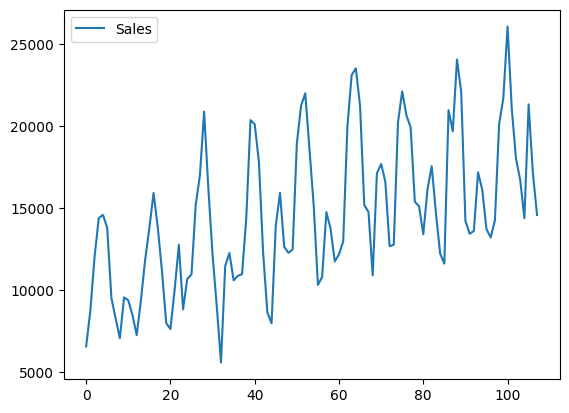

In [ ]:
# your code here
df.plot()

We can already start seeing some patterns, but let's see how we can use machines to make predictions for us!

### Preparing our data for Prophet

If we check the official [Prophet docs](https://facebook.github.io/prophet/docs/quick_start.html) we will see that there's a few conditions it asks of us:

1. Prophet needs the **datetime** column to be called `ds`
2. Prophet needs the **observations** column to be called `y`

First of all let's rename our columns correctly. That's as easy as just assigning a new list of columns, like this:

```python
df.columns = ['column1', 'column2']
```

In [ ]:
# your code here
df.columns = ['ds', 'y']

You might have noticed that our `Month` column (now called `ds`) doesn't have the right data type - it's current type is `object`. That's because `pandas` by default only sees text (which it calls `object`) and numbers.

We can use the built-in [pandas.to_datetime()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html) function to quickly change that! Notice that by itself, `pd.to_datetime()` function creates a *copy* of the column, so we need to save it back to the original columns, like so:

In [ ]:
# Your code here
df['ds'] = pd.to_datetime(df['ds'])

### Creating the Prophet prediction model

All Machine Learning tasks consist of the same steps:

1. Creating the model
2. Training the model (that's what takes the most time)
3. Using the model to predict
4. Evaluating the performance of the model

So, what are we waiting for?

**1. Creating the model**

At the top of this notebook we imported the `Prophet` *class*. This class is the "factory" which can help us create Prophet models. This is how it looks like:

In [ ]:
model = Prophet()

**2. Training the model**

We have a `model` ready, but it is not trained yet. That's our next step - we will give it our `df` DataFrame to *fit* an algorithm, which the machine will observe fits best all the historic observations we have.

> don't worry about the <span style='color: red;'>red text with `INFO`</span> that gets printed - it's just info logs to show you that the package is running

In [ ]:
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkcnmsakz/ob046lhl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkcnmsakz/i0ontnrq.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48467', 'data', 'file=/tmp/tmpkcnmsakz/ob046lhl.json', 'init=/tmp/tmpkcnmsakz/i0ontnrq.json', 'output', 'file=/tmp/tmpkcnmsakz/prophet_modeldzsuzv69/prophet_model-20251024101839.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
10:18:39 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:18:39 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


**Boom 💥** our `model` has found a "logic" that best explains the historic sales data. Now the caveat of Machine Learning in general is that often that "logic" is a **black box** ◼️ The model finds a formula that works for it, but as people we don't have much visibility into it.

But we can leverage it for **predictions!** 🔮

### Forecasting and predictions

When we talk about doing predictions programmatically, we talk about two types of predictions:

1. **In-sample** - we remove part of our historic data, and predict it with the model, to see how well it does
2. **Out-of-sample** (future predictions) - after verifying that our model "makes sense", we use it to generate future predictions

**In-sample** - Let's take the last 12 months of our existing dataset, and see how close are our model's predictions to the real sales

We can slice our DataFrame not only by columns (ex. `df['column']`) but also by rows, like this:

In [ ]:
df[100:102]

,ds,y
100,1968-05-01,26099
101,1968-06-01,21084


**Your turn! 🚀** So how do we get the **last 12 months** of the our DataFrame? 🤔


In [ ]:
# your code here
sample = df[-12:]
display(sample)

,ds,y
96,1968-01-01,13210
97,1968-02-01,14251
98,1968-03-01,20139
99,1968-04-01,21725
100,1968-05-01,26099
101,1968-06-01,21084
102,1968-07-01,18024
103,1968-08-01,16722
104,1968-09-01,14385
105,1968-10-01,21342


We are now ready to create a **forecast** - a DataFrame with predictions from our Prophet model.

In [ ]:
# Your code here
forecast = model.predict(sample)
display(forecast)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1968-01-01,17820.140687,12780.111357,15940.177767,17820.140687,17820.140687,-3462.551456,-3462.551456,-3462.551456,-3462.551456,-3462.551456,-3462.551456,0.0,0.0,0.0,14357.589231
1,1968-02-01,17875.817853,13442.379030,16542.837375,17875.817853,17875.817853,-2951.624176,-2951.624176,-2951.624176,-2951.624176,-2951.624176,-2951.624176,0.0,0.0,0.0,14924.193677
2,1968-03-01,17927.902944,19433.584803,22406.907099,17927.902944,17927.902944,2946.680899,2946.680899,2946.680899,2946.680899,2946.680899,2946.680899,0.0,0.0,0.0,20874.583843
3,1968-04-01,17983.580110,21300.045158,24540.527908,17983.580110,17983.580110,4915.186080,4915.186080,4915.186080,4915.186080,4915.186080,4915.186080,0.0,0.0,0.0,22898.766190
4,1968-05-01,18037.461239,22647.380841,25793.339258,18037.461239,18037.461239,6158.798635,6158.798635,6158.798635,6158.798635,6158.798635,6158.798635,0.0,0.0,0.0,24196.259875
5,1968-06-01,18093.138405,19359.976263,22563.371557,18093.138405,18093.138405,2967.220866,2967.220866,2967.220866,2967.220866,2967.220866,2967.220866,0.0,0.0,0.0,21060.359271
6,1968-07-01,18147.019534,16028.230376,19134.267100,18147.019534,18147.019534,-521.005191,-521.005191,-521.005191,-521.005191,-521.005191,-521.005191,0.0,0.0,0.0,17626.014343
7,1968-08-01,18202.696700,13828.127833,16982.378151,18202.696700,18202.696700,-2876.116760,-2876.116760,-2876.116760,-2876.116760,-2876.116760,-2876.116760,0.0,0.0,0.0,15326.579941
8,1968-09-01,18258.373867,12143.700839,15314.513430,18258.373867,18258.373867,-4499.988753,-4499.988753,-4499.988753,-4499.988753,-4499.988753,-4499.988753,0.0,0.0,0.0,13758.385113
9,1968-10-01,18312.254995,16575.844945,19809.434495,18312.254995,18312.254995,-142.160426,-142.160426,-142.160426,-142.160426,-142.160426,-142.160426,0.0,0.0,0.0,18170.094569


Wow that's a lot of stuff 🤯 We will explore what is what in a minute, but first let's first **visualize** our predictions, which would be much more human.

Find out how a Prophet model allows you to plot the predictions.

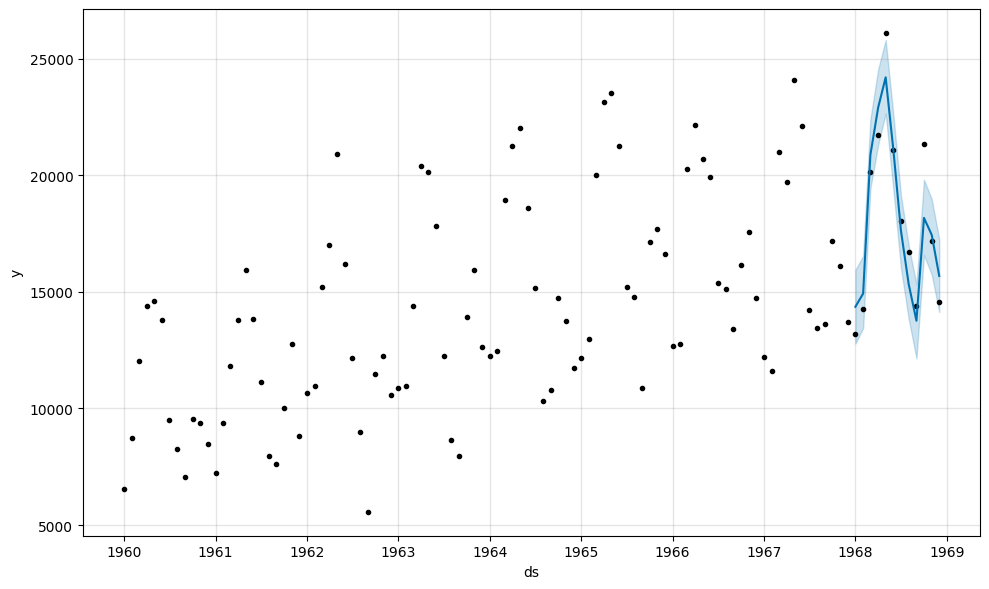

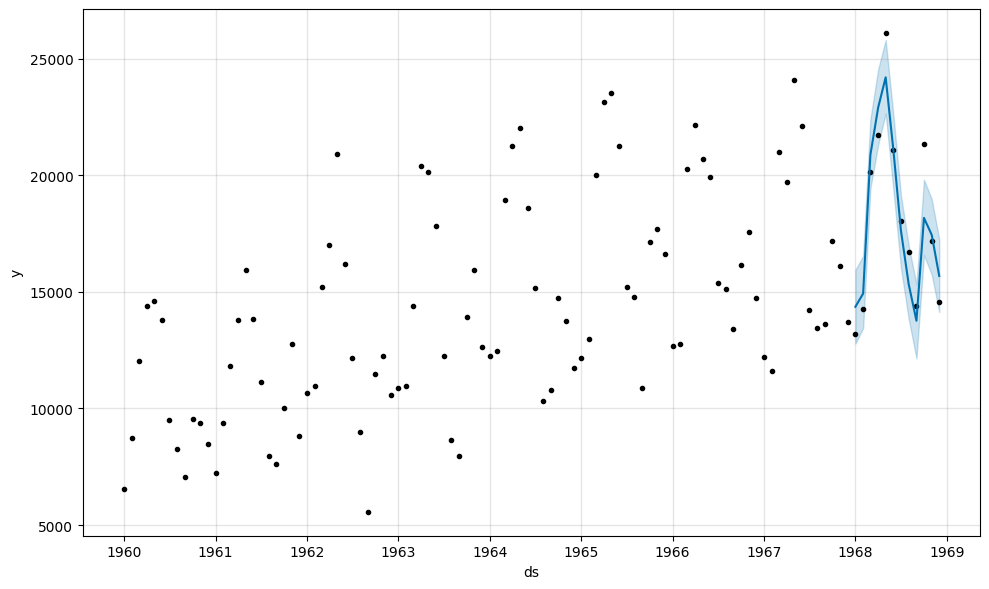

In [ ]:
# Your code here
model.plot(forecast)

The black dots in the chart above is the real data points.

The <span style='color: darkblue;'>dark blue line</span> is the predicted value - it's a line chart between the `yhat` points that we saw in the `forecast` DataFrame above.

The <span style='color: lightblue;'>light blue area</span> is the **confidence interval** - typically a 95% confidence window of the model prediction.

**[Bonus 🥇]** We can also add a **line chart** for the historic data to make it more visual:

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:975: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


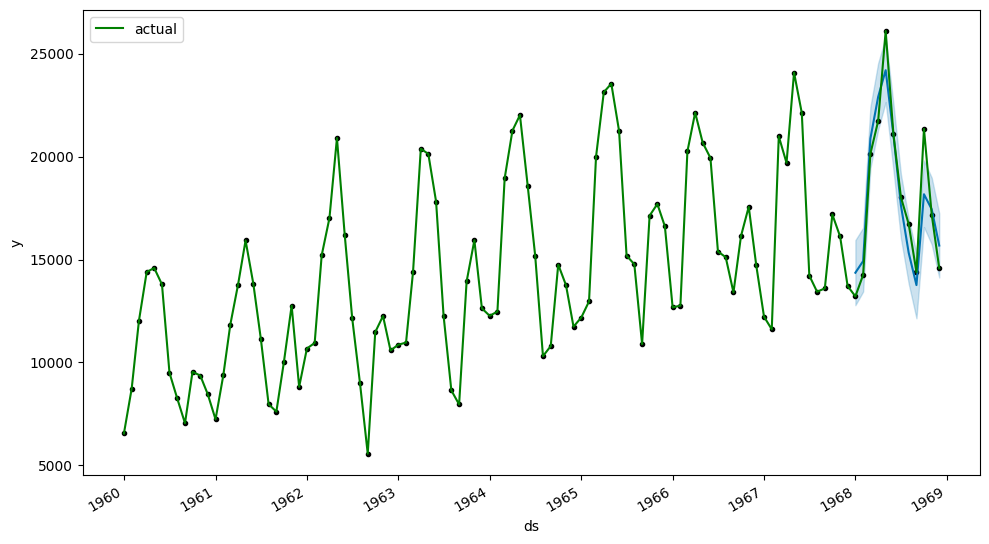

In [ ]:
ax = model.plot(forecast).gca()

df.plot(ax=ax, x='ds', y='y', label='actual', color='g');

**[Bonus Bonus 💥]** Looks like our model is fitting quite well! But **how well?** 🤔

We have the real data (`y` column) from our `sample`, and we have the predicted `yhat` from `forecast`.  Let's see the differences!

In [ ]:
difference = abs(forecast['yhat'].values - sample['y'].values) # abs gives us the absolute number
difference

array([1147.58923119,  673.19367684,  735.58384279, 1173.76619013,
       1902.74012549,   23.64072877,  397.98565707, 1395.42005947,
        626.61488665, 3171.9054308 ,  260.50926769, 1101.86246126])

From the above result we can see the **errors** - the difference between the predicted and actual car sales for the last 12 months.

Considering our car sales those months are between 15,000 ~ 25,000 cars, getting errors <1000 cars for most months is pretty good (for 20 minutes of work)! 🥳

Remember that this was the **in-sample** prediction. Now let's move on to **future forecasting! 🕵️‍♂️**

### Future Forecasting - out-of-sample (new data) predictions

Luckily `prophet` comes with some amazing tools for predictions, including the [`make_future_dataframe()`](https://facebook.github.io/prophet/docs/non-daily_data.html) method which allows us to quickly create a set of future dates to use for prediction. And it automatically turns it into a `DataFrame` 🙌

In [ ]:
# Your code here - Use 'MS' for the frequency, and forecast 3 years ahead.
future = model.make_future_dataframe(periods=3*12, freq='MS')
display(future.tail())

,ds
139,1971-08-01
140,1971-09-01
141,1971-10-01
142,1971-11-01
143,1971-12-01


You'll see that what it does is **append** the new months to the existing data - very useful, since we want to connect the two for an uninterrupted chart.

🚀 The prediction code is the same as before, only now we will be using the `future` DataFrame, not the `sample` any more.

In [ ]:
# Your code here
future_forecast = model.predict(future)
display(future_forecast.tail())

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
139,1971-08-01,20169.357897,15047.863731,18229.481344,20002.998073,20325.002990,-3512.307571,-3512.307571,-3512.307571,-3512.307571,-3512.307571,-3512.307571,0.0,0.0,0.0,16657.050326
140,1971-09-01,20225.035063,13643.549904,16895.012157,20050.386273,20386.039188,-4897.740167,-4897.740167,-4897.740167,-4897.740167,-4897.740167,-4897.740167,0.0,0.0,0.0,15327.294895
141,1971-10-01,20278.916191,18178.326657,21447.104802,20095.600218,20448.007256,-455.068816,-455.068816,-455.068816,-455.068816,-455.068816,-455.068816,0.0,0.0,0.0,19823.847375
142,1971-11-01,20334.593358,19491.606948,22561.501118,20143.410518,20509.792810,610.748051,610.748051,610.748051,610.748051,610.748051,610.748051,0.0,0.0,0.0,20945.341409
143,1971-12-01,20388.474486,16291.832953,19530.838670,20189.075850,20570.141899,-2509.030025,-2509.030025,-2509.030025,-2509.030025,-2509.030025,-2509.030025,0.0,0.0,0.0,17879.444462


🚀 Let's go ahead and plot it same way as we did before with the `model`.

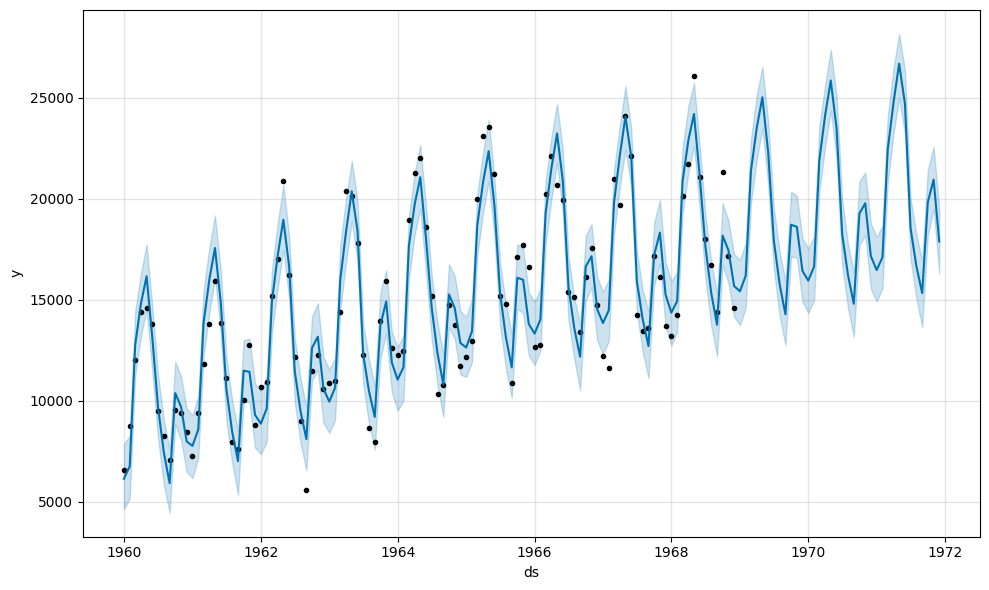

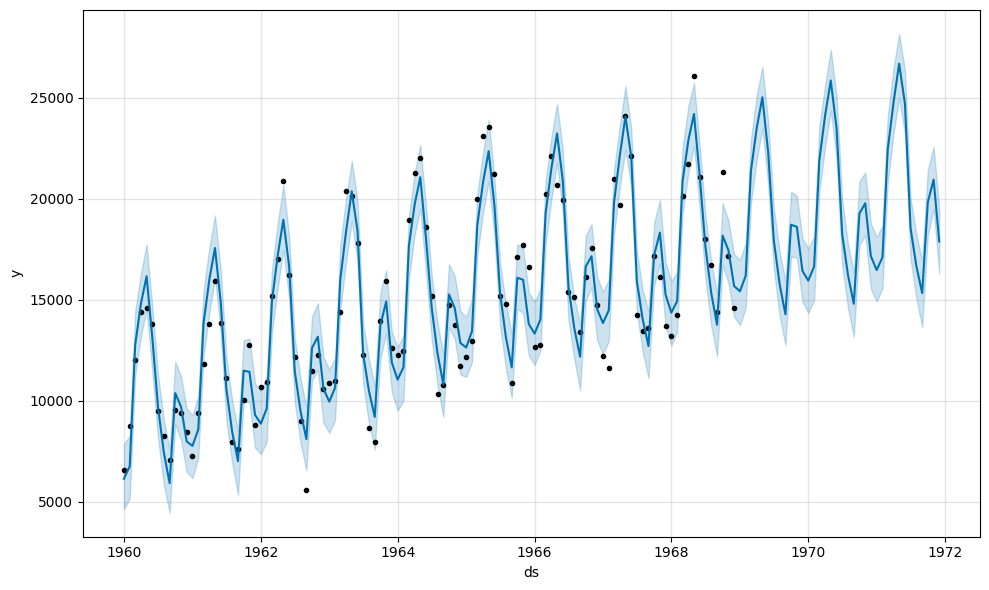

In [ ]:
# Your code here
model.plot(future_forecast)

### Congrats! 👏 This is your first prediction on unseen data!

You can also see how the model looks for patterns in historic data, but without **overfitting** - you can see that some black dots are not covered by the blue area. Which is normal, because not every month of car sales follows the same pattern, we've all had better and worse months 😉

**Let's explore our results further**

### Seasonality and Trend

To understand our results better, we need to explore the **components** that influence our car sales. The main two are seasonality and trend:

- **Seasonality** is the waves in our data. Looking at those can help find patterns of highs and lows.
- **Trend** is the general direction of the data. This helps us see whether we're increasing or decreasing over time.

And again `prophet` has helpful functions ready to use - let's use the [`plot_components()`](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html) function on our `model`.

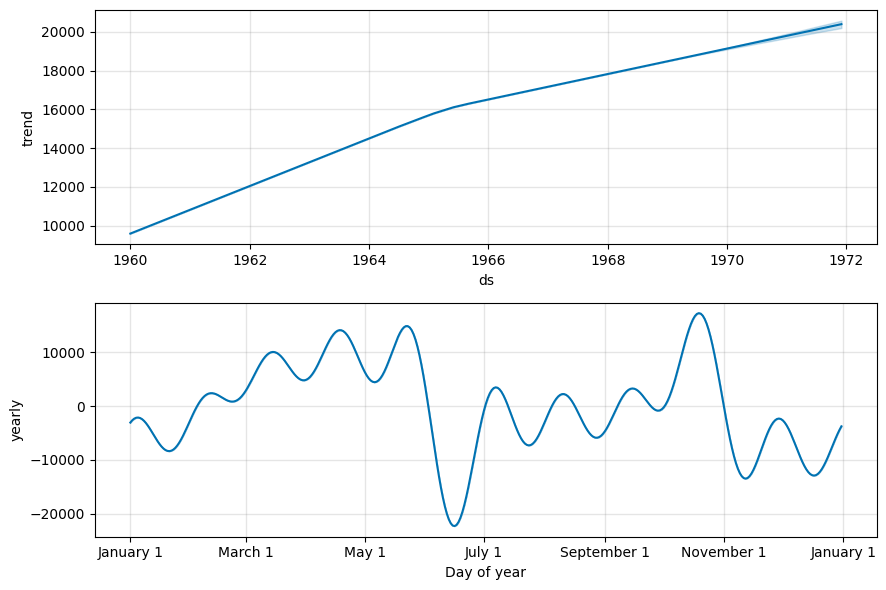

In [ ]:
model.plot_components(future_forecast);

**[Bonus 🥇]** We can make our plots interactive with another Python library called [Plotly](https://plotly.com/python/):

In [ ]:
from prophet.plot import plot_plotly

plot_plotly(model, future_forecast)

### Model Evaluation - Advanced and very OPTIONAL

We can't jump to conclusions on our model and trust it blindly. Even though we got a low error (difference) when looking at existing data, we need to look at some other important **metrics** to confidently say that our model can help the company! 🏎️

`prophet` comes with a handy [Diagnostics](https://facebook.github.io/prophet/docs/diagnostics.html) library built in.

Let's start by doing [cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)) - a technique in statistics, to run through the same process multiple times (instead of just one like we did above), and see how consistent are our results. Run the below two cells:

In [ ]:
from prophet.diagnostics import cross_validation

In [ ]:
df_cv = cross_validation(model, period='730 days', horizon='365 days')

INFO:prophet:Making 3 forecasts with cutoffs between 1963-12-03 00:00:00 and 1967-12-02 00:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpkcnmsakz/p74fvxal.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkcnmsakz/jihafnvs.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27214', 'data', 'file=/tmp/tmpkcnmsakz/p74fvxal.json', 'init=/tmp/tmpkcnmsakz/jihafnvs.json', 'output', 'file=/tmp/tmpkcnmsakz/prophet_modeldzt75umm/prophet_model-20251024102405.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
10:24:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
10:24:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkcnmsakz/z19b_4kv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkcnmsakz/os6ep8vj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local

As we saw, this took longer than a regular model training and prediction. That's because it ran the process **10 times**, each time taking a piece of the data as the "seen" data, and predicting the next period, as though it is "unseen", trying to predict up to one year ahead each time. Robots are tricky, eh? 🤖

In [ ]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1964-01-01,11487.946242,10415.054611,12614.835915,12267,1963-12-03
1,1964-02-01,12331.978597,11263.642229,13395.124007,12470,1963-12-03
2,1964-03-01,17415.939944,16325.646277,18463.730823,18944,1963-12-03
3,1964-04-01,18638.438796,17476.786434,19806.630686,21259,1963-12-03
4,1964-05-01,19782.037518,18735.238158,20809.458419,22015,1963-12-03
5,1964-06-01,18050.859686,17047.404012,19094.860931,18581,1963-12-03
6,1964-07-01,14397.384884,13344.138553,15514.179864,15175,1963-12-03
7,1964-08-01,12506.239074,11427.171070,13586.323395,10306,1963-12-03
8,1964-09-01,11250.678389,10174.973754,12288.157402,10792,1963-12-03
9,1964-10-01,13440.523914,12414.206751,14545.825263,14752,1963-12-03


If you look inside the `df_cv` variable, you'll see that we're storing a bunch of data about the real car sales throughout the years (`y` column), the predicted sales (`yhat`) as well as the `cutoff`s - the time blocks used to simulate "unseen" data, so we can better understand our model performance.

You might notice already not everything is as rosy as it seemed 🥀

But we did **all this in a short time**! Imagine what **you can do with more time!!! 🤩**

### Wrapping up - interpretation

To close our current exploration and prediction, let's visualize the `mae` - [**Mean Absolute Error**](https://en.wikipedia.org/wiki/Mean_absolute_erro). This is the average difference that we're getting between the real car sales and predicted ones.

Remember, when we looked at *in-sample* prediction, our average MAE was around 1000 cars. Let's see how much harder *real* predictions get 🙈

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.

/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.



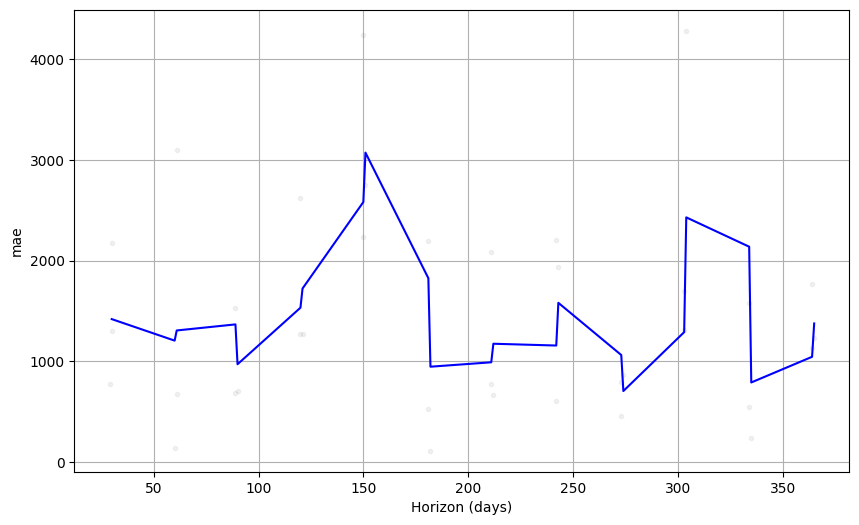

In [ ]:
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric='mae')

### Explaining these results to your boss 💹

Let's explore the chart above:
* Our horizontal (`x`) axis is how many days into the future we're predicting. As you can see, we tried to predict up to a maximum of 365 days (1 year). That's our **horizon**
* Our vertical (`y`) axis is the **Mean Absolute Error** - the average error in our predictions in car sales. We can see we are typically making errors of around 1000-2000 cars.

**Our best case interpretation:**

We can see some clear highs and lows in our errors, which is not good. :( The main reason for that is that our data is `monthly` but we are doing our cross-validation `by day`.

Still, it seems that **our predictions are best at `around 3 to 6 months into the future`, where we are able to `predict with 95% confidence the car sales, with an error of ±1300 cars`.**

Before and after that the **volatility** (waviness) or errors becomes too big to say anything with certainty. Your boss will be happy you did your research 🤓

# Congrats on completing this challenge! 🙌 There's always more to learn!